# Customer Loan Approval Prediction
--- 

### Data Cleaning
---

In [9]:
# importing the required libraries  
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# reading the dataset
df = pd.read_csv('..\\datasets\\loan_data.csv')
print(df.head())

   person_age person_gender person_education  person_income  person_emp_exp  \
0       22.00        female           Master      71,948.00               0   
1       21.00        female      High School      12,282.00               0   
2       25.00        female      High School      12,438.00               3   
3       23.00        female         Bachelor      79,753.00               0   
4       24.00          male           Master      66,135.00               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT  35,000.00    PERSONAL          16.02   
1                   OWN   1,000.00   EDUCATION          11.14   
2              MORTGAGE   5,500.00     MEDICAL          12.87   
3                  RENT  35,000.00     MEDICAL          15.23   
4                  RENT  35,000.00     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                        3.00           561  

#### Statistical summary of the dataset:
---

In [11]:
print("Description of the dataset (numeric):")
pd.set_option('display.float_format', '{:,.2f}'.format)
print(df.describe())


Description of the dataset (numeric):
       person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
count   45,000.00      45,000.00       45,000.00  45,000.00      45,000.00   
mean        27.76      80,319.05            5.41   9,583.16          11.01   
std          6.05      80,422.50            6.06   6,314.89           2.98   
min         20.00       8,000.00            0.00     500.00           5.42   
25%         24.00      47,204.00            1.00   5,000.00           8.59   
50%         26.00      67,048.00            4.00   8,000.00          11.01   
75%         30.00      95,789.25            8.00  12,237.25          12.99   
max        144.00   7,200,766.00          125.00  35,000.00          20.00   

       loan_percent_income  cb_person_cred_hist_length  credit_score  \
count            45,000.00                   45,000.00     45,000.00   
mean                  0.14                        5.87        632.61   
std                   0.09                 

In [12]:
print("\nDescription of the dataset (categorical):")
print(df.describe(include='str'))



Description of the dataset (categorical):
       person_gender person_education person_home_ownership loan_intent  \
count          45000            45000                 45000       45000   
unique             2                5                     4           6   
top             male         Bachelor                  RENT   EDUCATION   
freq           24841            13399                 23443        9153   

       previous_loan_defaults_on_file  
count                           45000  
unique                              2  
top                               Yes  
freq                            22858  


In [13]:
print("\nDataset information:")
print(df.info())



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_default

In [14]:
print("\nNumber of missing values in each column:")
print(df.isnull().sum())


Number of missing values in each column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [15]:
# checking the duplicates rows
print(df.duplicated().sum())

0


---

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["person_gender"] = le.fit_transform(df["person_gender"])
df["previous_loan_defaults_on_file"] = le.fit_transform(df["previous_loan_defaults_on_file"])

In [18]:
education_mapping = {
    "High School": 0,
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "Doctorate": 4
}

df["person_education"] = df["person_education"].map(education_mapping)


In [19]:
df = pd.get_dummies(df,columns=["person_home_ownership","loan_intent"],drop_first=True)

In [20]:
print(df.dtypes)

person_age                        float64
person_gender                       int64
person_education                    int64
person_income                     float64
person_emp_exp                      int64
loan_amnt                         float64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file      int64
loan_status                         int64
person_home_ownership_OTHER          bool
person_home_ownership_OWN            bool
person_home_ownership_RENT           bool
loan_intent_EDUCATION                bool
loan_intent_HOMEIMPROVEMENT          bool
loan_intent_MEDICAL                  bool
loan_intent_PERSONAL                 bool
loan_intent_VENTURE                  bool
dtype: object


In [21]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.00,0,3,"71,948.00",0,"35,000.00",16.02,0.49,3.00,561,0,1,False,False,True,False,False,False,True,False
1,21.00,0,0,"12,282.00",0,"1,000.00",11.14,0.08,2.00,504,1,0,False,True,False,True,False,False,False,False
2,25.00,0,0,"12,438.00",3,"5,500.00",12.87,0.44,3.00,635,0,1,False,False,False,False,False,True,False,False
3,23.00,0,2,"79,753.00",0,"35,000.00",15.23,0.44,2.00,675,0,1,False,False,True,False,False,True,False,False
4,24.00,1,3,"66,135.00",1,"35,000.00",14.27,0.53,4.00,586,0,1,False,False,True,False,False,True,False,False


In [23]:
# saving the cleaned csv into new csv file
df.to_csv('..\\datasets\\loan_data_cleaned.csv', index= False)

---

## EDA Exploratory Data Analysis
---

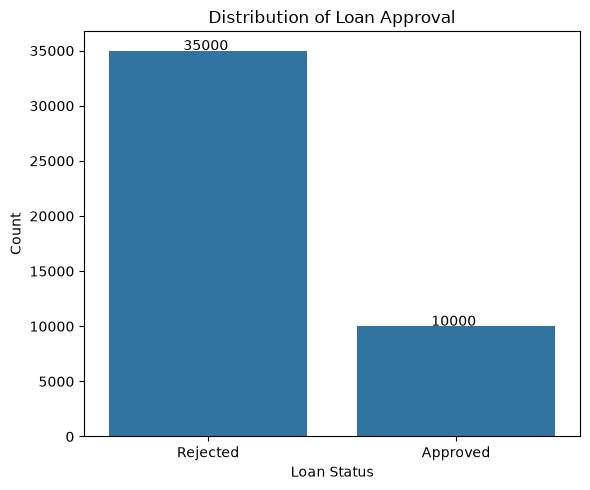

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='loan_status')

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.xticks([0,1],["Rejected","Approved"])

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x()+0.3,p.get_height()+50))

plt.tight_layout()
plt.show()

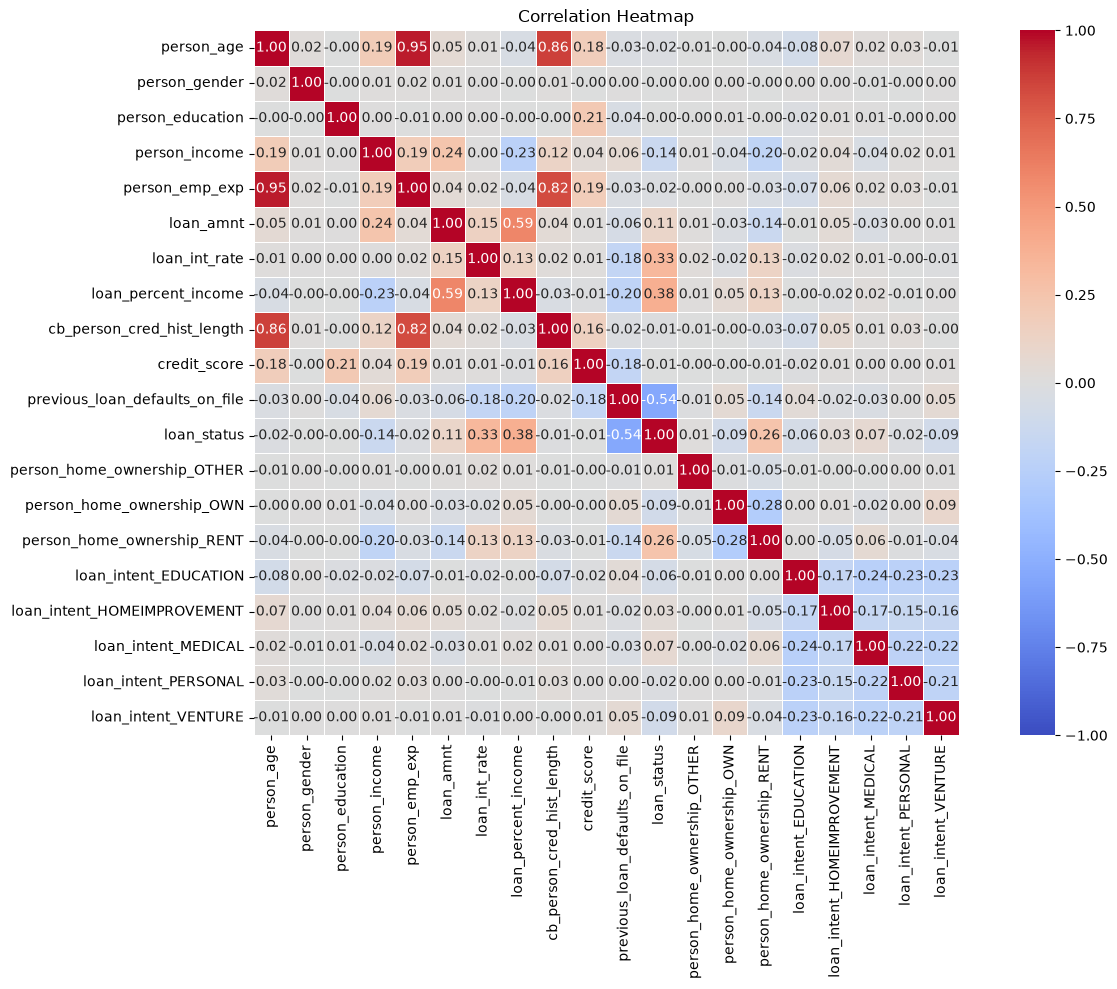

In [27]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,
            square=True,vmin=-1,vmax=1,center=0)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

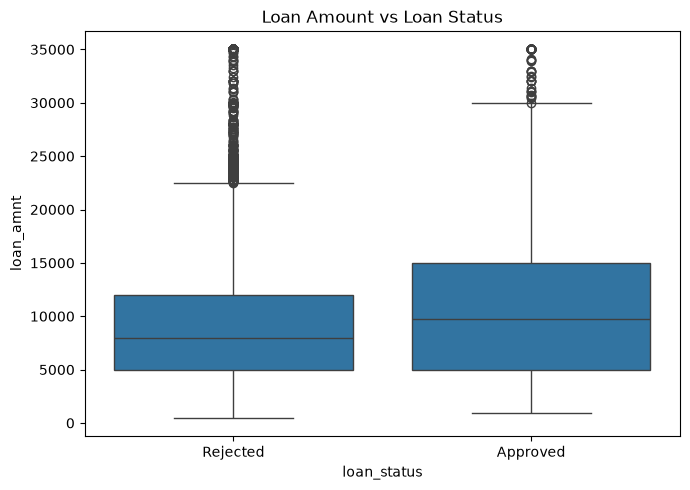

In [28]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="loan_status",y="loan_amnt")

plt.xticks([0,1],["Rejected","Approved"])
plt.title("Loan Amount vs Loan Status")

plt.tight_layout()
plt.show()

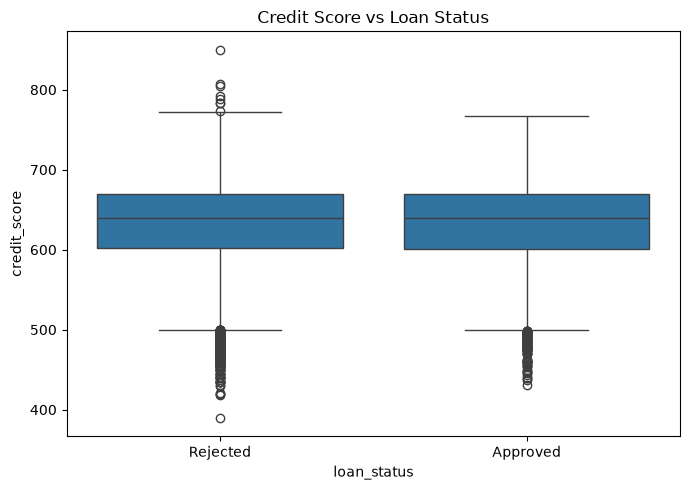

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="loan_status",y="credit_score")

plt.xticks([0,1],["Rejected","Approved"])
plt.title("Credit Score vs Loan Status")

plt.tight_layout()
plt.show()

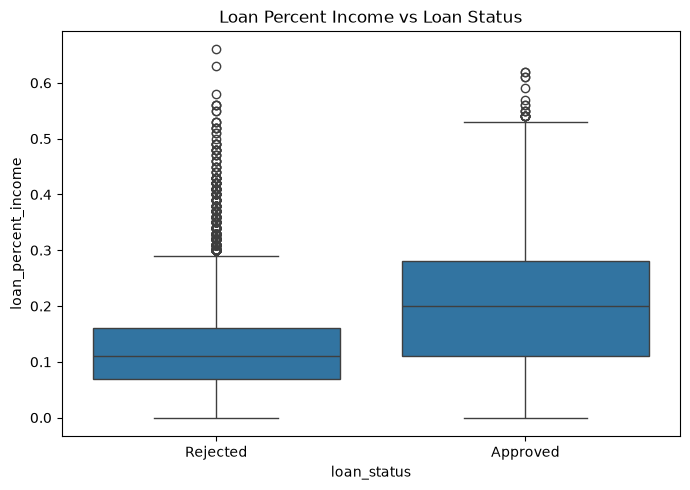

In [30]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="loan_status",y="loan_percent_income")

plt.xticks([0,1],["Rejected","Approved"])
plt.title("Loan Percent Income vs Loan Status")

plt.tight_layout()
plt.show()